# Logistic Regression & Random Forest
**ShipmentSure — Predicting On-Time Delivery**

- Logistic Regression as a linear, interpretable baseline
- Random Forest as a non-linear benchmark
- GridSearchCV for hyperparameter tuning
- Full evaluation: accuracy, precision, recall, F1, ROC-AUC, confusion matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load processed data (saved by Data_Pipeline_Preprocessing.ipynb)
# Fallback: generate from raw if processed files don't exist yet
try:
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
    y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()
    print("Loaded processed data.")
except FileNotFoundError:
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder

    df = pd.read_csv('../data/Train.csv')
    if 'ID' in df.columns:
        df = df.drop('ID', axis=1)
    X = df.drop('Reached.on.Time_Y.N', axis=1)
    y = df['Reached.on.Time_Y.N'].values

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include='object').columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ])

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)
    print("Generated processed data from raw.")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loaded processed data.
Train: (800, 19), Test: (200, 19)


In [3]:
# Logistic Regression with hyperparameter tuning
print("Tuning Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {'C': [0.1, 1, 10], 'penalty': ['l2']}
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)
lr_best = grid_lr.best_estimator_
print(f"Best params: {grid_lr.best_params_}")

Tuning Logistic Regression...
Best params: {'C': 0.1, 'penalty': 'l2'}


In [4]:
# Random Forest with hyperparameter tuning
print("Tuning Random Forest...")
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_
print(f"Best params: {grid_rf.best_params_}")

Tuning Random Forest...
Best params: {'max_depth': 10, 'n_estimators': 50}


In [5]:
# Evaluate both models
def evaluate_model(model, name, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1-Score': f1_score(y, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y, y_prob)
    }, confusion_matrix(y, y_pred), y_prob

models = {'Logistic Regression': lr_best, 'Random Forest': rf_best}
all_metrics = []
cm_dict = {}
prob_dict = {}

for name, model in models.items():
    metrics, cm, probs = evaluate_model(model, name, X_test, y_test)
    all_metrics.append(metrics)
    cm_dict[name] = cm
    prob_dict[name] = probs

results_df = pd.DataFrame(all_metrics).sort_values('F1-Score', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.540   0.545455 0.534653  0.540000 0.567257
      Random Forest     0.545   0.552083 0.524752  0.538071 0.531753


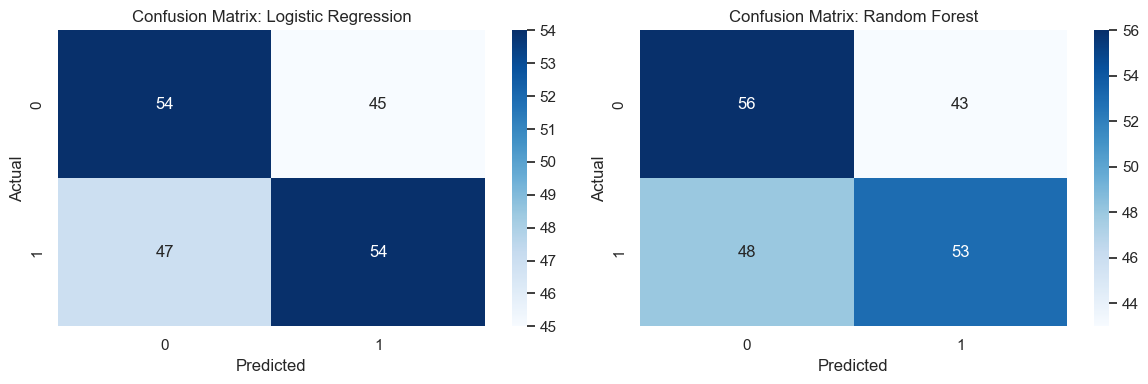

In [6]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

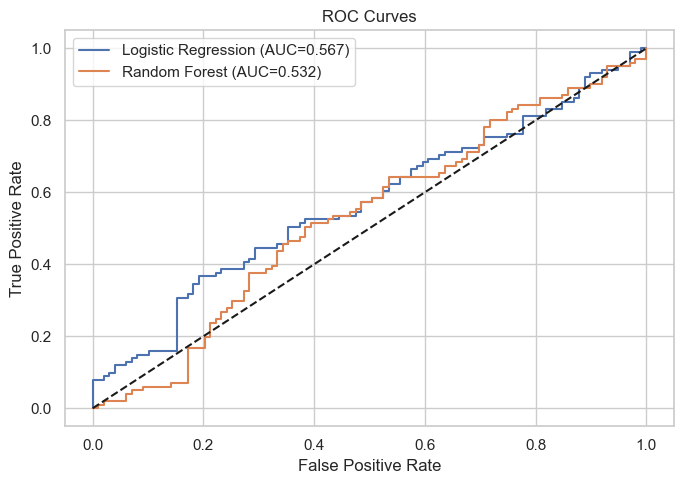

In [7]:
# ROC Curves
plt.figure(figsize=(7, 5))
for name, probs in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Classification report for best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Classification Report — {best_model_name}:")
print(classification_report(y_test, best_model.predict(X_test)))

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

           0       0.53      0.55      0.54        99
           1       0.55      0.53      0.54       101

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.54      0.54       200

